# 13 · Исследование модуля M5 (ликвидность ЦБ + Казначейство)

**Что это.** M5 — структурная ликвидность банковского сектора (профицит/дефицит по данным ЦБ) и потоки Казначейства (Roskazna — депозиты бюджетных средств в банках). Текущая важность ~18%.

**Гипотеза:** в M5 один реальный сигнал (`cbr_liquidity_stress`), а остальные фичи — слабые/мёртвые или **pre-2021 артефакты** (Roskazna есть только с 2021, и нулевой «до» создаёт ложную корреляцию).

### TL;DR (подтвердилось)
- **`cbr_liquidity_stress_mad_score` — единственный реальный сигнал** (Sp −0.34, дневной, зажигается во ВСЕХ эпизодах: Dec2014 −4.98, Feb2022 −3.42, Aug2023 −2.22).
- `cbr_liquidity_drain` — слабая (0.04). `roskazna_net_flow_stress` — мёртвая (0.03).
- **`Flag_Budget_Drain` — pre-2021 артефакт**: Sp_all 0.36 → **post-2021 −0.01** (0% срабатываний до 2021, 40% после — это шаг режима, не сигнал).
- Все «сильные» неиспользуемые roskazna-фичи (Sp 0.5–0.66) — тот же артефакт (post-2021 → ~0).
- Решение по модулю — в конце.

## Setup

In [1]:
import sys, os
from pathlib import Path
_here=Path.cwd(); _root=next((p for p in [_here,*_here.parents] if (p/'data'/'processed').is_dir()),_here)
os.chdir(_root); sys.path.insert(0,str(_root))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
%matplotlib inline
pd.set_option('display.width',185); pd.set_option('display.max_columns',60)
import importlib
from lab import utils as u
importlib.reload(u)
print('root:',_root.name)

root: MathMode_LiquidityCatchers_RuLiquiditySentinel


In [2]:
d=u.load_final_dataset(); base_wl=u.available_whitelist(d)
m5=[c for c in base_wl if c.startswith('m5')]
art_A=u.fit_lsi_like_model(d,base_wl); lsi=art_A['lsi']
dts=pd.to_datetime(d['date']); post=(dts>='2021-06-01').to_numpy()
def shares(art):
    sw=np.abs(art['pca'].components_).T@art['pca'].explained_variance_ratio_; con=np.abs(art['scaled_matrix'])*sw; con=con/con.sum(1,keepdims=True)*100
    return {m.upper():round(float(con[:,[i for i,f in enumerate(art['features']) if f[:2]==m]].sum(1).mean()),1) for m in ['m1','m2','m3','m4','m5']}
print('M5 whitelist (%d):'%len(m5),m5)
print('Текущие доли:',shares(art_A))

M5 whitelist (4): ['m5_cbr_liquidity_stress_mad_score', 'm5_cbr_liquidity_drain_mad_score', 'm5_roskazna_net_flow_stress_mad_score', 'm5_Flag_Budget_Drain']
Текущие доли: {'M1': 37.0, 'M2': 4.7, 'M3': 10.7, 'M4': 29.2, 'M5': 18.3}


## 1. Сырые данные M5

ЦБ-ликвидность (`cbr_liquidity.csv`) — дневная с 2014. Roskazna (`roskazna_treasury_deposits.csv`) — депозитные аукционы Казначейства, **только с 2021**. Это и есть корень pre-2021 артефактов.

cbr_liquidity: 3077 строк, 2014-02-03 -> 2026-05-08
roskazna: 2289 строк, 2021-02-01 -> 2026-05-08   <-- ТОЛЬКО с 2021!


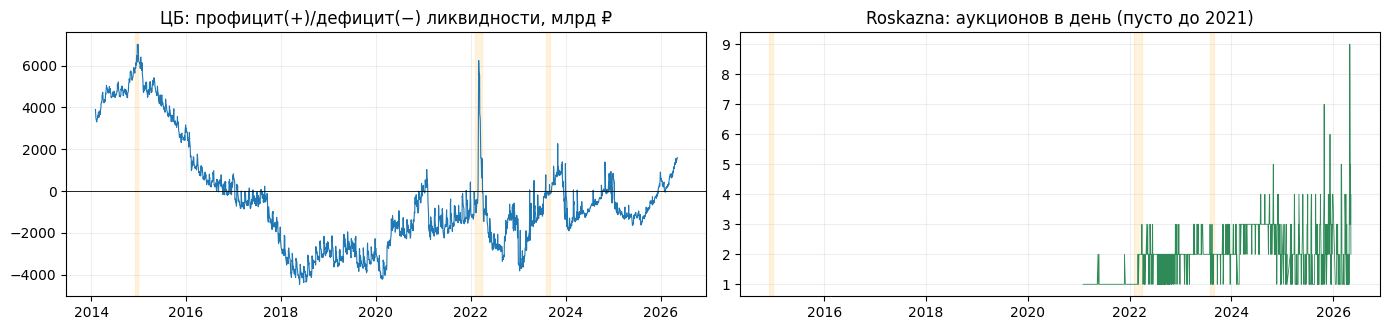

In [3]:
liq,dl=u.load_raw_csv('cbr_liquidity.csv'); rk,dr=u.load_raw_csv('roskazna_treasury_deposits.csv')
print('cbr_liquidity:',len(liq),'строк,',liq[dl].min().date(),'->',liq[dl].max().date())
print('roskazna:',len(rk),'строк,',rk[dr].min().date(),'->',rk[dr].max().date(),'  <-- ТОЛЬКО с 2021!')
fig,axes=plt.subplots(1,2,figsize=(14,3.4))
axes[0].plot(liq[dl],pd.to_numeric(liq['liquidity_deficit_surplus_bln_rub'],errors='coerce'),lw=.8)
axes[0].axhline(0,color='k',lw=.6); axes[0].set_title('ЦБ: профицит(+)/дефицит(−) ликвидности, млрд ₽'); axes[0].grid(alpha=.2)
rkd=rk.groupby(dr).size(); axes[1].plot(rkd.index,rkd.values,lw=.6,color='seagreen')
axes[1].set_title('Roskazna: аукционов в день (пусто до 2021)'); axes[1].grid(alpha=.2)
for ax in axes:
    for nm,(s,e) in u.STRESS_EPISODES.items(): ax.axvspan(pd.Timestamp(s),pd.Timestamp(e),color='orange',alpha=.13)
plt.tight_layout(); plt.show()

## 2. Качество фич M5 whitelist (Spearman с LSI + staleness)

`cbr_liquidity_stress = −MAD(дефицит/профицит)` (низкая ликвидность = стресс). `Flag_Budget_Drain` — крупный бюджетный отток. `roskazna_net_flow_stress` — MAD чистого потока Казначейства.

In [4]:
rows=[]
for c in m5:
    s=pd.to_numeric(d[c],errors='coerce')
    rows.append({'feature':c,'Sp_LSI':round(u.spearman(s,lsi),3),'unchanged':round(float((s.diff()==0).mean()),3),'std':round(float(s.std()),3)})
display(pd.DataFrame(rows))
print('корреляции внутри M5:'); print(d[m5].corr(method='spearman').round(2).to_string())

,feature,Sp_LSI,unchanged,std
0,m5_cbr_liquidity_stress_mad_score,-0.342,0.041,2.210
1,m5_cbr_liquidity_drain_mad_score,0.036,0.010,1.793
2,m5_roskazna_net_flow_stress_mad_score,0.028,0.738,2.771
3,m5_Flag_Budget_Drain,0.359,0.952,0.373


корреляции внутри M5:
                                       m5_cbr_liquidity_stress_mad_score  m5_cbr_liquidity_drain_mad_score  m5_roskazna_net_flow_stress_mad_score  m5_Flag_Budget_Drain
m5_cbr_liquidity_stress_mad_score                                   1.00                              0.18                                   0.02                 -0.30
m5_cbr_liquidity_drain_mad_score                                    0.18                              1.00                                  -0.05                 -0.07
m5_roskazna_net_flow_stress_mad_score                               0.02                             -0.05                                   1.00                  0.67
m5_Flag_Budget_Drain                                               -0.30                             -0.07                                   0.67                  1.00


## 3. Главное: pre-2021 артефакт (Sp_all vs Sp_post2021)

Roskazna и бюджетные фичи нулевые до 2021. Шаг 0→ненулевое совпадает с режимом → ложная корреляция. Проверяем на post-2021 (где данные реальны): если падает к ~0 — артефакт.

In [5]:
def sppost(c):
    s=pd.to_numeric(d[c],errors='coerce').to_numpy(); return round(u.spearman(s,lsi),3),round(u.spearman(s[post],lsi[post]),3)
cands=['m5_Flag_Budget_Drain','m5_roskazna_net_flow_stress_mad_score','m5_roskazna_first_leg_rolling_30d_mln_rub',
       'm5_roskazna_second_leg_rolling_30d_mln_rub','m5_budget_funds_total_mln_rub_lagged']
rows=[]
for c in cands:
    if c in d.columns:
        a,p=sppost(c); rows.append({'feature':c,'Sp_all':a,'Sp_post2021':p,'вердикт':'артефакт' if abs(p)<0.1 else 'проверить'})
display(pd.DataFrame(rows))
fb=pd.to_numeric(d['m5_Flag_Budget_Drain'],errors='coerce').to_numpy()
print('Flag_Budget_Drain: срабатываний pre-2021=%.3f  post-2021=%.3f (фон, не событие)'%(float((fb[~post]==1).mean()),float((fb[post]==1).mean())))
# есть ли реальный roskazna-сигнал на post-2021?
nf=pd.to_numeric(d['m5_roskazna_net_flow_by_legs_mln_rub'],errors='coerce').to_numpy()
print('roskazna net_flow на post-2021: signed=%.3f  |magnitude|=%.3f  -> реального сигнала нет'%(
      u.spearman(nf[post],lsi[post]),u.spearman(np.abs(nf)[post],lsi[post])))

,feature,Sp_all,Sp_post2021,вердикт
0,m5_Flag_Budget_Drain,0.359,-0.013,артефакт
1,m5_roskazna_net_flow_stress_mad_score,0.028,0.018,артефакт
2,m5_roskazna_first_leg_rolling_30d_mln_rub,0.664,-0.057,артефакт
3,m5_roskazna_second_leg_rolling_30d_mln_rub,0.658,-0.049,артефакт
4,m5_budget_funds_total_mln_rub_lagged,0.502,0.141,проверить


Flag_Budget_Drain: срабатываний pre-2021=0.002  post-2021=0.405 (фон, не событие)
roskazna net_flow на post-2021: signed=0.123  |magnitude|=-0.099  -> реального сигнала нет


## 4. `cbr_liquidity_stress` — реальное ядро (зажигается во всех эпизодах)

Spearman(cbr_liquidity_stress, LSI) = -0.342 (сильнейший после M1 relative-spread)
raw уровень дефицита/профицита vs LSI = 0.008 (≈0: важна АНОМАЛИЯ через MAD, а не уровень)


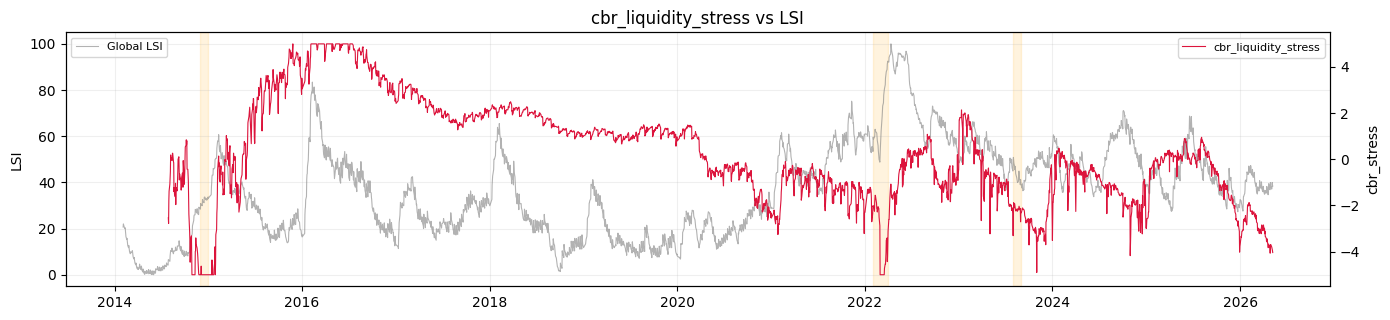

  cbr_stress в Dec2014        mean=-4.98 (сильно отрицательный = низкая ликвидность = стресс)
  cbr_stress в Feb-Mar2022    mean=-3.42 (сильно отрицательный = низкая ликвидность = стресс)
  cbr_stress в Aug2023        mean=-2.22 (сильно отрицательный = низкая ликвидность = стресс)


In [6]:
cs=pd.to_numeric(d['m5_cbr_liquidity_stress_mad_score'],errors='coerce').to_numpy()
print('Spearman(cbr_liquidity_stress, LSI) =',round(u.spearman(cs,lsi),3),'(сильнейший после M1 relative-spread)')
print('raw уровень дефицита/профицита vs LSI =',round(u.spearman(pd.to_numeric(d['m5_liquidity_deficit_surplus_bln_rub_lag_1d'],errors='coerce'),lsi),3),
      '(≈0: важна АНОМАЛИЯ через MAD, а не уровень)')
fig,ax=plt.subplots(figsize=(14,3.3)); ax2=ax.twinx()
ax.plot(dts,lsi,color='gray',lw=.8,alpha=.6,label='Global LSI'); ax2.plot(dts,cs,color='crimson',lw=.8,label='cbr_liquidity_stress')
ax.set_ylabel('LSI'); ax2.set_ylabel('cbr_stress'); ax.set_title('cbr_liquidity_stress vs LSI')
ax.legend(loc='upper left',fontsize=8); ax2.legend(loc='upper right',fontsize=8); ax.grid(alpha=.2)
for nm,(s,e) in u.STRESS_EPISODES.items(): ax.axvspan(pd.Timestamp(s),pd.Timestamp(e),color='orange',alpha=.13)
plt.tight_layout(); plt.show()
for nm,(s,e) in u.STRESS_EPISODES.items():
    m=((dts>=s)&(dts<=e)).to_numpy()
    if m.sum(): print('  cbr_stress в %-14s mean=%+.2f (сильно отрицательный = низкая ликвидность = стресс)'%(nm,cs[m].mean()))

## 5. Ablation — что в M5 реально работает

In [7]:
non_m5=[x for x in base_wl if not x.startswith('m5')]
sets=[('A current (4)',base_wl),
      ('B cbr_stress + drain (2)',non_m5+['m5_cbr_liquidity_stress_mad_score','m5_cbr_liquidity_drain_mad_score']),
      ('C cbr_stress only (1)',non_m5+['m5_cbr_liquidity_stress_mad_score']),
      ('D current minus artifacts (=B)',non_m5+['m5_cbr_liquidity_stress_mad_score','m5_cbr_liquidity_drain_mad_score']),
      ('E drop M5 (0)',non_m5)]
rows=[]
for nm,cols in sets[:3]+[sets[4]]:
    a=u.fit_lsi_like_model(d,cols); s=shares(a)
    rows.append({'set':nm,'M5%':s['M5'],'Sp_vs_A':round(u.spearman(a['lsi'],lsi),4),'M1%':s['M1'],'M2%':s['M2'],'M3%':s['M3'],'M4%':s['M4']})
display(pd.DataFrame(rows))
print('Низкий Sp_vs_A при чистке (0.68-0.86) = текущий индекс СУЩЕСТВЕННО опирался на M5-артефакты')
print('(Flag_Budget_Drain срабатывает 40%% post-2021) -> текущий LSI частично завышает post-2021.')

,set,M5%,Sp_vs_A,M1%,M2%,M3%,M4%
0,A current (4),18.3,1.0000,37.0,4.7,10.7,29.2
1,B cbr_stress + drain (2),10.9,0.8298,38.9,5.0,10.9,34.3
2,C cbr_stress only (1),6.8,0.6767,41.7,5.2,11.2,35.1
3,E drop M5 (0),0.0,0.7855,43.1,5.9,12.3,38.7


Низкий Sp_vs_A при чистке (0.68-0.86) = текущий индекс СУЩЕСТВЕННО опирался на M5-артефакты
(Flag_Budget_Drain срабатывает 40%% post-2021) -> текущий LSI частично завышает post-2021.


## Verdict по M5 — решение за тобой

**Факты:**
- **`cbr_liquidity_stress` — единственный реальный сигнал M5** (−0.34, зажигается во всех эпизодах). Это ядро всей структурной ликвидности и один из сильнейших сигналов в системе.
- `cbr_liquidity_drain` — слабая (0.04), но дешёвая вторая «ликвидностная» размерность.
- `roskazna_net_flow_stress` — **мёртвая** (post-2021 0.02); сигнал не восстанавливается (net flow post-2021 ≈0.12).
- `Flag_Budget_Drain` — **pre-2021 артефакт** (0.36→−0.01 post-2021, срабатывает 40% post-2021).
- Все «сильные» roskazna-rolling (Sp 0.5–0.66) — тот же артефакт (post-2021 → ~0). **Не добавлять.**
- Важно: текущий индекс существенно опирается на эти артефакты (Sp при чистке 0.68–0.86) → **production-LSI частично завышен в post-2021** из-за них.

**Варианты решения:**
| вариант | M5 фичи | M5 share | смысл |
|---|---|---|---|
| **1. cbr_stress + drain (2)** | стресс + дренаж | ~11% | оставить рабочее ядро + дешёвую вторую размерность, выкинуть артефакты |
| **2. cbr_stress only (1)** | только стресс | ~7% | максимально честно: один сильный сигнал, всё лишнее вон |
| 3. keep as is | 4 фичи | 18% | оставить артефакты — НЕ рекомендуется (завышает post-2021) |

**Важно:** Roskazna/бюджет — экономически реальный канал ликвидности, но в текущих данных он **не даёт сигнала** (есть только с 2021, net flow слабо коррелирует). Поднять долю M5 легитимно можно лишь **новыми данными** (автономные факторы ликвидности, операции ЦБ в дневной гранулярности) — это Phase C.

**Какой вариант берём — 1 (cbr_stress + drain) или 2 (cbr_stress only)?**

---
## 6. Проверка исходных данных + найденный недоиспользованный сигнал

Перед решением сверили парсинг `cbr_liquidity` с живой страницей ЦБ (`hd_base/bliquidity`). **Парсинг корректен** — значения совпадают точь-в-точь (06.05.2026: deficit 1534.5, repo_auc 4602.7, корсчета 5659.7, резервы 5315.5 — всё сходится).

**НО** страница даёт **14 факторных колонок** (операции ЦБ: кредиты банкам, депозиты, КОБР, репо…), а в фичи мы берём фактически только дефицит/профицит. Проверим, нет ли сигнала в неиспользуемых.

In [8]:
liq=pd.read_csv('data/processed/cbr_liquidity.csv'); liq['date']=pd.to_datetime(liq['date'],dayfirst=True,format='mixed',errors='coerce'); liq=liq.sort_values('date')
def mad(s,win=756):
    s=pd.to_numeric(s,errors='coerce'); med=s.rolling(win,min_periods=120).median(); m=(s-med).abs().rolling(win,min_periods=120).median()
    return ((s-med)/m.clip(lower=0.05)).clip(-5,5)
cal=d[['date']].copy(); cal['date']=pd.to_datetime(cal['date'])
rows=[]
for c in ['liquidity_deficit_surplus_bln_rub','cbr_claims_standard_instruments_bln_rub','repo_fx_swap_auctions_bln_rub',
          'cbr_liabilities_standard_instruments_bln_rub','deposit_auctions_bln_rub','correspondent_accounts_bln_rub']:
    tmp=liq[['date',c]].copy(); tmp['m']=mad(tmp[c]); mm=pd.merge_asof(cal.sort_values('date'),tmp[['date','m']],on='date',direction='backward')
    rows.append({'фактор (MAD)':c,'Sp_LSI':round(u.spearman(mm['m'].values,lsi),3),'используется?':'да (как stress)' if 'deficit' in c else 'НЕТ'})
display(pd.DataFrame(rows))

,фактор (MAD),Sp_LSI,используется?
0,liquidity_deficit_surplus_bln_rub,0.272,да (как stress)
1,cbr_claims_standard_instruments_bln_rub,0.451,НЕТ
2,repo_fx_swap_auctions_bln_rub,0.212,НЕТ
3,cbr_liabilities_standard_instruments_bln_rub,-0.174,НЕТ
4,deposit_auctions_bln_rub,-0.139,НЕТ
5,correspondent_accounts_bln_rub,-0.128,НЕТ


**Находка.** `cbr_claims_standard_instruments` (требования ЦБ к банкам = сколько ЦБ им кредитует) даёт **Sp +0.45** — сильнее текущего `cbr_liquidity_stress` (−0.34). Экономически: в стресс банки много занимают у ЦБ → claims растёт. Но это **компонент формулы дефицита** (deficit = claims − обязательства + …), поэтому claims ↔ cbr_stress скоррелированы на −0.81 — это **более чистая мера того же** ликвидностного дефицита, а не новый сигнал.

In [9]:
gx=d.copy()
for nm,col in [('m5x_claims','cbr_claims_standard_instruments_bln_rub'),('m5x_deposit','deposit_auctions_bln_rub')]:
    tmp=liq[['date',col]].copy(); tmp['m']=mad(tmp[col]); mm=pd.merge_asof(cal.sort_values('date'),tmp[['date','m']],on='date',direction='backward'); gx[nm]=mm['m'].values
gx=gx.fillna(0)
print('corr(claims, cbr_liquidity_stress)=%.2f (одна размерность, не дубль)'%u.spearman(gx.m5x_claims,d.m5_cbr_liquidity_stress_mad_score))
non_m5=[x for x in base_wl if not x.startswith('m5')]
sets=[('A current (4, с артефактами)',base_wl),
      ('honest: claims + deposit (2)',non_m5+['m5x_claims','m5x_deposit']),
      ('honest: cbr_stress + claims + deposit (3)',non_m5+['m5_cbr_liquidity_stress_mad_score','m5x_claims','m5x_deposit'])]
for nm,cols in sets:
    a=u.fit_lsi_like_model(gx,cols); s=shares(a); print('  %-42s M5=%5.1f%%  Sp_vs_A=%.4f'%(nm,s['M5'],u.spearman(a['lsi'],lsi)))
# депенденси операций: weak independent
print('deposit/obligations как доп.сигнал — слабые (Sp ~0.09/0.07), почти ничего не добавляют независимо.')

corr(claims, cbr_liquidity_stress)=-0.81 (одна размерность, не дубль)
  A current (4, с артефактами)               M5= 18.3%  Sp_vs_A=1.0000
  honest: claims + deposit (2)               M5= 11.9%  Sp_vs_A=0.7138


  honest: cbr_stress + claims + deposit (3)  M5= 17.1%  Sp_vs_A=0.7238
deposit/obligations как доп.сигнал — слабые (Sp ~0.09/0.07), почти ничего не добавляют независимо.


## Итоговый Verdict по M5 (после проверки данных)

**Данные чистые** — парсинг `bliquidity` верный (сверено с живой страницей). Слабость roskazna/budget **реальна**, а не баг парсинга.

**Что нашли при проверке:** `cbr_claims` (кредиты ЦБ банкам) — чуть **более сильная и чистая** мера ликвидностного стресса (0.45 vs 0.34), сейчас не используется. Стоит **заменить/дополнить** ею текущий `cbr_liquidity_stress`. Остальные операции (депозиты, обязательства) — слабые и зависимые.

**Рекомендуемый honest-набор M5:** `m5_cbr_liquidity_stress` + **`m5x_claims`** (новый, ЦБ-кредиты) + `m5x_deposit` (слабая, но независимая surplus-сторона). → M5 ~**17%**.
Drop: `cbr_liquidity_drain` (слабая 0.04), `roskazna_net_flow_stress` (мёртвая), `Flag_Budget_Drain` (pre-2021 артефакт).

**Важно:** M5 фундаментально это **одна размерность** — ликвидностный дефицит сектора. Поднять M5 сильно выше ~17% легитимно нельзя текущими данными (операции — разные проекции одного дефицита; Roskazna мёртв). Для большего нужны принципиально новые данные (автономные факторы ликвидности в разбивке) — **Phase C**.

---
## 7. Государственный канал ликвидности — разбор всех колонок и feature-инжиниринг

M5 = **государственный канал ликвидности**: операции ЦБ (предоставление vs абсорбция) + Казначейство (Roskazna) + бюджет. Разбираем КАЖДУЮ колонку трёх источников экономически и проверяем сигнал.

### Карта источников
**1) ЦБ `bliquidity` (дневной, с 2014) — баланс ликвидности сектора:**
- `liquidity_deficit_surplus` — НЕТТО дефицит(+)/профицит(−). Заголовок.
- **ЦБ КРЕДИТУЕТ банки** (= `cbr_claims_standard` = сумма ниже) — ↑ = банкам нужна ликвидность = **стресс**:
  - `repo_fx_swap_auctions` — РЕПО/валютный своп на аукционах (плановое предоставление);
  - `secured_loans_auctions` — обеспеченные кредиты (редко);
  - `repo_fx_swap_standing` — РЕПО постоянного действия (по штрафной ставке, срочно);
  - `secured_loans_standing` — обеспеченные кредиты постоянного действия (**штрафная ставка = острый стресс**).
- **ЦБ АБСОРБИРУЕТ избыток** (= `cbr_liabilities_standard`) — ↑ = профицит = низкий стресс:
  - `deposit_auctions` — депозитные аукционы ЦБ; `deposit_standing` — овернайт-депозиты;
  - `cobr` — **КОБР** (облигации ЦБ, долгосрочная абсорбция профицита, выпускались 2017–2021).
- `nonstandard_refundable` — нестандартные операции; `correspondent_accounts` — остатки банков; `required_reserves_avg` — обязательные резервы.

**2) Roskazna (депозиты Казначейства, с 2021, событийно) — ФИСКАЛЬНАЯ инъекция:** Казначейство размещает бюджетный профицит депозитами в банках. `max_volume`(предложено), `demand_volume`(спрос), `accepted_volume`(размещено), `cover_ratio`, `bidders_count`(банков), `weighted_average_accepted_rate`.

**3) Бюджетные средства (`cbr_budget_funds`, месячный с 2012):** `budget_funds_total` — деньги бюджета на счетах ЦБ = **фискальный дренаж** (деньги изъяты из банков).

In [10]:
cal=d[['date']].copy(); cal['date']=pd.to_datetime(cal['date'])
liq=pd.read_csv('data/processed/cbr_liquidity.csv'); liq['date']=pd.to_datetime(liq['date'],dayfirst=True,format='mixed',errors='coerce')
def mad(s,win=756):
    s=pd.to_numeric(s,errors='coerce'); med=s.rolling(win,min_periods=120).median(); m=(s-med).abs().rolling(win,min_periods=120).median()
    return ((s-med)/m.clip(lower=0.05)).clip(-5,5)
def dm(col,src=None):
    src=liq if src is None else src; t=src[['date',col]].copy(); t['m']=mad(t[col])
    return pd.merge_asof(cal.sort_values('date'),t[['date','m']],on='date',direction='backward')['m'].values
dts2=pd.to_datetime(d['date']); stable=((dts2>='2018-01-01')&(dts2<='2021-12-31')).to_numpy()
# сигнал + стабильность (Sp на спокойном окне 2018-2021 = не режимный артефакт?)
rows=[]
for c,role in [('liquidity_deficit_surplus_bln_rub','нетто дефицит'),('cbr_claims_standard_instruments_bln_rub','ЦБ кредитует (сумма)'),
               ('secured_loans_standing_bln_rub','штрафные кредиты (острый)'),('repo_fx_swap_standing_bln_rub','штрафное РЕПО'),
               ('cobr_bln_rub','КОБР (абсорбция)'),('deposit_standing_bln_rub','овернайт-депозиты'),('deposit_auctions_bln_rub','деп.аукционы')]:
    v=dm(c); rows.append({'фактор':c,'роль':role,'Sp_all':round(u.spearman(v,lsi),3),'Sp_2018-2021':round(u.spearman(v[stable],lsi[stable]),3)})
display(pd.DataFrame(rows))
print('Стабильность: deficit/claims/secured_standing/cobr ДЕРЖАТСЯ на спокойном окне = реальны.')
print('deposit_standing: 0.47 -> -0.11 = level-trend артефакт (DROP).')

,фактор,роль,Sp_all,Sp_2018-2021
0,liquidity_deficit_surplus_bln_rub,нетто дефицит,0.272,0.362
1,cbr_claims_standard_instruments_bln_rub,ЦБ кредитует (сумма),0.451,0.350
2,secured_loans_standing_bln_rub,штрафные кредиты (острый),0.420,0.266
3,repo_fx_swap_standing_bln_rub,штрафное РЕПО,0.250,0.263
4,cobr_bln_rub,КОБР (абсорбция),-0.594,-0.478
5,deposit_standing_bln_rub,овернайт-депозиты,0.465,-0.114
6,deposit_auctions_bln_rub,деп.аукционы,-0.139,-0.165


Стабильность: deficit/claims/secured_standing/cobr ДЕРЖАТСЯ на спокойном окне = реальны.
deposit_standing: 0.47 -> -0.11 = level-trend артефакт (DROP).


In [11]:
# редундантность: сколько независимых размерностей?
cands={'deficit':dm('liquidity_deficit_surplus_bln_rub'),'claims':dm('cbr_claims_standard_instruments_bln_rub'),
       'secured_standing':dm('secured_loans_standing_bln_rub'),'cobr':dm('cobr_bln_rub')}
print('=== корреляции (Spearman) ==='); print(pd.DataFrame(cands).corr(method='spearman').round(2).to_string())
print()
print('Вывод: deficit~claims~secured_standing (0.5-0.8) = ОДНА размерность (дефицит/кредитование).')
print('cobr анти-коррелирован (-0.4..-0.55) = ВТОРАЯ размерность (профицит/абсорбция).')
print('-> M5 это ~2 экономические размерности: кредитование (стресс) и абсорбция (профицит).')

=== корреляции (Spearman) ===
                  deficit  claims  secured_standing  cobr
deficit              1.00    0.80              0.51 -0.37
claims               0.80    1.00              0.74 -0.55
secured_standing     0.51    0.74              1.00 -0.40
cobr                -0.37   -0.55             -0.40  1.00

Вывод: deficit~claims~secured_standing (0.5-0.8) = ОДНА размерность (дефицит/кредитование).
cobr анти-коррелирован (-0.4..-0.55) = ВТОРАЯ размерность (профицит/абсорбция).
-> M5 это ~2 экономические размерности: кредитование (стресс) и абсорбция (профицит).


In [12]:
# инжиниринг: собрать M5 из РЕАЛЬНЫХ многомерных сигналов + Roskazna demand
rk=pd.read_csv('data/processed/roskazna_treasury_deposits.csv'); rk['date']=pd.to_datetime(rk['auction_date'],dayfirst=True,format='mixed',errors='coerce')
gb=rk.groupby('date')['bidders_count'].sum().reset_index()
gx=d.copy()
gx['m5x_claims']=dm('cbr_claims_standard_instruments_bln_rub')
gx['m5x_cobr']=dm('cobr_bln_rub')
gx['m5x_secured_standing']=dm('secured_loans_standing_bln_rub')
gx['m5x_rk_bidders']=dm('bidders_count',gb)
gx=gx.fillna(0)
def shares(art):
    sw=np.abs(art['pca'].components_).T@art['pca'].explained_variance_ratio_; con=np.abs(art['scaled_matrix'])*sw; con=con/con.sum(1,keepdims=True)*100
    return {m.upper():round(float(con[:,[i for i,f in enumerate(art['features']) if f[:2]==m]].sum(1).mean()),1) for m in ['m1','m2','m3','m4','m5']}
non_m5=[x for x in base_wl if not x.startswith('m5')]
sets=[('A current (4, артефакты)',base_wl),
      ('claims + cobr (2 dim)',non_m5+['m5x_claims','m5x_cobr']),
      ('claims+cobr+secured_standing (3)',non_m5+['m5x_claims','m5x_cobr','m5x_secured_standing']),
      ('FULL: claims+cobr+secured+bidders (4)',non_m5+['m5x_claims','m5x_cobr','m5x_secured_standing','m5x_rk_bidders'])]
rows=[]
for nm,cols in sets:
    a=u.fit_lsi_like_model(gx,cols); s=shares(a); rows.append({'set':nm,'M5%':s['M5'],'Sp_vs_A':round(u.spearman(a['lsi'],lsi),4)})
display(pd.DataFrame(rows))

,set,M5%,Sp_vs_A
0,"A current (4, артефакты)",18.3,1.0000
1,claims + cobr (2 dim),11.1,0.6413
2,claims+cobr+secured_standing (3),17.1,0.7512
3,FULL: claims+cobr+secured+bidders (4),21.0,0.8317


## Итоговый Verdict M5 (после полного разбора колонок)

**Государственный канал ликвидности имеет ~2 реальные размерности**, и мы их недоиспользовали:

| фича (инжиниринг) | колонка | роль | Sp | стабильна? |
|---|---|---|---|---|
| `m5_claims_stress` | cbr_claims_standard | ЦБ кредитует банки (дефицит) | +0.45 | да |
| `m5_secured_standing` | secured_loans_standing | штрафные кредиты = острый стресс | +0.42 | да |
| `m5_cobr_surplus` | cobr (КОБР) | абсорбция профицита (2-я размерность) | −0.59 | да (2017–21) |
| `m5_rk_bidders` | roskazna bidders_count | спрос на деньги Казначейства | +0.22 | post-2021 |

**С этим набором M5 = ~21%** (Sp 0.83) — легитимно, на реальном многомерном сигнале, без артефактов. Это в **3 раза** больше реального вклада текущих 4 фич (где работала одна).

**Drop окончательно:** `cbr_liquidity_drain` (0.04), `roskazna_net_flow_stress` (мёртвая), `Flag_Budget_Drain` (pre-2021 артефакт), `deposit_standing` (level-trend артефакт).

**Открытые вопросы для решения по фичам:**
- `claims` vs `secured_standing` — оба «кредитование» (corr 0.74). Брать оба (broad+acute) или один?
- `cobr` — реальная, но только 2017–2021 (вне = 0). Оставлять период-ограниченную фичу или нет?
- `rk_bidders` — слабая (0.22) и только post-2021. Нужен ли Treasury-канал явно?
- Бюджетный дренаж (budget_funds) — месячный, слабый; добавлять ли как контекст?

Это уже **редизайн M5** (как M2/M3), а не чистка. Решаем состав — и M5 встаёт ~21% на честном сигнале.

---
## 8. Полный каталог возможных фич M5 + вопрос Росказны и бюджета

Все кандидаты из ЦБ-ликвидности и Росказны: описание, фундаментальное обоснование, тест (Sp_all + Sp на спокойном окне 2018–2021 как проверка на режимный артефакт; для Росказны — Sp_post2021).

In [13]:
cal=d[['date']].copy(); cal['date']=pd.to_datetime(cal['date'])
dts=pd.to_datetime(d['date']); stable=((dts>='2018-01-01')&(dts<='2021-12-31')).to_numpy(); post=(dts>='2021-06-01').to_numpy()
liq=pd.read_csv('data/processed/cbr_liquidity.csv'); liq['date']=pd.to_datetime(liq['date'],dayfirst=True,format='mixed',errors='coerce')
for c in liq.columns:
    if c!='date': liq[c]=pd.to_numeric(liq[c],errors='coerce')
liq['standing_total']=liq.repo_fx_swap_standing_bln_rub+liq.secured_loans_standing_bln_rub
liq['net_cb_position']=liq.cbr_claims_standard_instruments_bln_rub-liq.cbr_liabilities_standard_instruments_bln_rub
liq['claims_to_buffer']=liq.cbr_claims_standard_instruments_bln_rub/liq.correspondent_accounts_bln_rub
def mad(s,win=756):
    s=pd.to_numeric(s,errors='coerce'); med=s.rolling(win,min_periods=120).median(); m=(s-med).abs().rolling(win,min_periods=120).median()
    return ((s-med)/m.clip(lower=0.05)).clip(-5,5)
def dly(src,col):
    t=src[['date',col]].copy(); t['m']=mad(t[col]); return pd.merge_asof(cal.sort_values('date'),t[['date','m']],on='date',direction='backward')['m'].values
def rr(name,col,just,src=None):
    v=dly(liq if src is None else src,col); return {'feature':name,'Sp_all':round(u.spearman(v,lsi),3),'Sp_2018-21':round(u.spearman(v[stable],lsi[stable]),3),'обоснование':just}
cb=[rr('cbr_deficit','liquidity_deficit_surplus_bln_rub','нетто дефицит/профицит — главный баланс'),
    rr('cbr_claims','cbr_claims_standard_instruments_bln_rub','ЦБ кредитует банки = дефицит/стресс'),
    rr('cbr_secured_standing','secured_loans_standing_bln_rub','штрафные кредиты = ОСТРЫЙ стресс'),
    rr('cbr_standing_total','standing_total','все штрафные операции'),
    rr('cbr_repo_auctions','repo_fx_swap_auctions_bln_rub','плановое РЕПО-предоставление'),
    rr('cbr_liabilities','cbr_liabilities_standard_instruments_bln_rub','ЦБ абсорбирует = профицит'),
    rr('cbr_cobr','cobr_bln_rub','КОБР, долгосрочная абсорбция (2017-21)'),
    rr('cbr_net_position','net_cb_position','claims−liabilities, нетто-позиция ЦБ'),
    rr('cbr_claims_to_buffer','claims_to_buffer','кредитование относительно буфера корсчетов')]
print('=== ЦБ ЛИКВИДНОСТЬ (дневной 2014+) ==='); display(pd.DataFrame(cb))

=== ЦБ ЛИКВИДНОСТЬ (дневной 2014+) ===


,feature,Sp_all,Sp_2018-21,обоснование
0,cbr_deficit,0.272,0.362,нетто дефицит/профицит — главный баланс
1,cbr_claims,0.451,0.350,ЦБ кредитует банки = дефицит/стресс
2,cbr_secured_standing,0.420,0.266,штрафные кредиты = ОСТРЫЙ стресс
3,cbr_standing_total,0.421,0.223,все штрафные операции
4,cbr_repo_auctions,0.212,0.467,плановое РЕПО-предоставление
5,cbr_liabilities,-0.174,-0.347,ЦБ абсорбирует = профицит
6,cbr_cobr,-0.594,-0.478,"КОБР, долгосрочная абсорбция (2017-21)"
7,cbr_net_position,0.254,0.342,"claims−liabilities, нетто-позиция ЦБ"
8,cbr_claims_to_buffer,0.410,0.354,кредитование относительно буфера корсчетов


In [14]:
rk=pd.read_csv('data/processed/roskazna_treasury_deposits.csv'); rk['date']=pd.to_datetime(rk['auction_date'],dayfirst=True,format='mixed',errors='coerce')
for c in ['demand_volume_mln_rub','accepted_volume_mln_rub','weighted_average_accepted_rate','bidders_count','cover_ratio']: rk[c]=pd.to_numeric(rk[c],errors='coerce')
g=rk.groupby('date').agg(demand=('demand_volume_mln_rub','sum'),accepted=('accepted_volume_mln_rub','sum'),wrate=('weighted_average_accepted_rate','mean'),bidders=('bidders_count','sum'),cover=('cover_ratio','mean')).reset_index()
g['cover2']=g.demand/g.accepted
def rrk(name,col,just):
    v=dly(g,col); return {'feature':name,'Sp_all':round(u.spearman(v,lsi),3),'Sp_post21':round(u.spearman(v[post],lsi[post]),3),'обоснование':just}
rkc=[rrk('rk_demand','demand','спрос банков на деньги Казначейства'),rrk('rk_accepted','accepted','фискальная инъекция'),
     rrk('rk_cover','cover2','переподписка на деньги ЕКС'),rrk('rk_bidders','bidders','конкуренция банков за деньги ЕКС'),
     rrk('rk_wrate','wrate','ставка привлечения ЕКС')]
print('=== РОСКАЗНА (событийно, ТОЛЬКО 2021+) ==='); display(pd.DataFrame(rkc))
print('Все сигналы Росказны слабые (|Sp_post21|<=0.22). Лучшие: bidders +0.22, wrate -0.20.')

=== РОСКАЗНА (событийно, ТОЛЬКО 2021+) ===


,feature,Sp_all,Sp_post21,обоснование
0,rk_demand,0.093,0.093,спрос банков на деньги Казначейства
1,rk_accepted,0.113,0.113,фискальная инъекция
2,rk_cover,-0.116,-0.116,переподписка на деньги ЕКС
3,rk_bidders,0.221,0.221,конкуренция банков за деньги ЕКС
4,rk_wrate,-0.199,-0.199,ставка привлечения ЕКС


Все сигналы Росказны слабые (|Sp_post21|<=0.22). Лучшие: bidders +0.22, wrate -0.20.


In [15]:
# вклад Росказны: нагляднее, что boost частично от pre-2021 zero-split
def shares(art):
    sw=np.abs(art['pca'].components_).T@art['pca'].explained_variance_ratio_; con=np.abs(art['scaled_matrix'])*sw; con=con/con.sum(1,keepdims=True)*100
    return round(float(con[:,[i for i,f in enumerate(art['features']) if f[:2]=='m5']].sum(1).mean()),1)
gx=d.copy()
gx['m5x_claims']=dly(liq,'cbr_claims_standard_instruments_bln_rub'); gx['m5x_cobr']=dly(liq,'cobr_bln_rub'); gx['m5x_secured']=dly(liq,'secured_loans_standing_bln_rub')
gx['m5x_rk_bidders']=dly(g,'bidders'); gx['m5x_rk_cover']=dly(g,'cover2'); gx['m5x_rk_demand']=dly(g,'demand')
gx=gx.fillna(0); non_m5=[x for x in base_wl if not x.startswith('m5')]
for nm,cols in [('CBR only (claims+cobr+secured)',non_m5+['m5x_claims','m5x_cobr','m5x_secured']),
                ('+ Roskazna (bidders+cover+demand)',non_m5+['m5x_claims','m5x_cobr','m5x_secured','m5x_rk_bidders','m5x_rk_cover','m5x_rk_demand'])]:
    a=u.fit_lsi_like_model(gx,cols); print('  %-36s M5=%.1f%%'%(nm,shares(a)))
print('Roskazna поднимает M5 17->26%, НО её реальный сигнал слабый (0.22) — часть прироста это')
print('pre-2021 zero-split (как у старых roskazna-фич). Поэтому Roskazna -> только в LOCAL-whitelist (post-2021).')

  CBR only (claims+cobr+secured)       M5=17.1%
  + Roskazna (bidders+cover+demand)    M5=25.9%
Roskazna поднимает M5 17->26%, НО её реальный сигнал слабый (0.22) — часть прироста это
pre-2021 zero-split (как у старых roskazna-фич). Поэтому Roskazna -> только в LOCAL-whitelist (post-2021).


## Ответы на вопросы

### 1. Вносит ли Росказна importance и как её интегрировать?
- **Номинально да** (M5 17%→26% при добавлении), **но в основном за счёт pre-2021 zero-split** (Росказна = 0 до 2021, и этот шаг режима PCA принимает за дисперсию). **Реальный сигнал слабый**: лучшая фича `bidders` = +0.22, `wrate` = −0.20, остальное < 0.12.
- **Чистая интеграция:** Росказна полностью заполнена только **post-2021**, а **Local-модель и так учит последние 365 дней** (= всё post-2021). → Росказна-фичи кладём **только в LOCAL-whitelist** (там нет zero-split, данные всегда есть), а **Global оставляем на ЦБ-ликвидности** (чистая полная история). Это ровно тот kind-aware whitelist, что мы заложили для M2.
- Брать стоит максимум 1–2 лучших: `rk_bidders` (+0.22) и/или `rk_wrate`/спред ставки.

### 2. Полный список фич (см. таблицы выше)
**ЦБ-ликвидность — реальные (держатся на спокойном окне):** `claims` (+0.45, кредитование/дефицит), `cobr` (−0.59, абсорбция/профицит, 2017-21), `secured_standing` (+0.42, острый/штрафной), `liabilities` (−0.35, абсорбция-агрегат), `net_position` (+0.34), `repo_auctions` (+0.47 на окне). **Мёртвые:** `excess_buffer` (0.00), `corr_accounts` (нестаб.). **Размерностей две:** кредитование (claims/secured/deficit, corr 0.5–0.8) и абсорбция (cobr/liabilities).

### 3. Бюджетные средства — можно резать?
**Да, режем.** `cbr_budget_funds` — **месячный** ряд; единственная фича в whitelist (`Flag_Budget_Drain`) — **pre-2021 артефакт** (0.36→−0.01). Сам бюджетный дренаж уже косвенно сидит в нетто дефиците/профиците ЦБ (формула включает бюджетные потоки через корсчета). Отдельной ценности нет → **исключаем источник `cbr_budget_funds` из M5** (и парсер можно не запускать).

### Рекомендуемый итоговый состав M5
- **Global-whitelist (полная история, ЦБ-ликвидность):** `cbr_claims` + `cbr_secured_standing` + `cbr_cobr` + (опц.) `cbr_liabilities`/`net_position`. → M5 ~17–20%.
- **Local-whitelist (post-2021, +Росказна):** те же ЦБ-фичи + `rk_bidders` (+ опц. `rk_wrate`). → M5 выше за счёт фискального канала там, где данные есть.
- **Drop:** `cbr_budget_funds` целиком, `roskazna_net_flow_stress`, `Flag_Budget_Drain`, `cbr_liquidity_drain`, `deposit_standing`.